In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/primus11/cic-ids-2018-dataset/cic.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os, json, joblib, warnings
warnings.filterwarnings('ignore')

import shap
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance

os.makedirs('models', exist_ok=True)
RANDOM = 42
np.random.seed(RANDOM)
PAL = ['#4f7cff','#22c55e','#f59e0b','#ef4444','#8b5cf6','#06b6d4']
print('NB5 imports ready.')

NB5 imports ready.


In [3]:
# Load from NB1 — same CSV
CSV_PATH = '/kaggle/input/datasets/primus11/cic-ids-2018-dataset/cic.csv'
df_raw   = pd.read_csv(CSV_PATH, low_memory=False)

FEATURE_COLS = [c for c in [
    'Dst Port','Protocol','Flow Duration',
    'Tot Fwd Pkts','Tot Bwd Pkts','TotLen Fwd Pkts','TotLen Bwd Pkts',
    'Fwd Pkt Len Max','Fwd Pkt Len Min','Fwd Pkt Len Mean','Fwd Pkt Len Std',
    'Bwd Pkt Len Max','Bwd Pkt Len Min','Bwd Pkt Len Mean','Bwd Pkt Len Std',
    'Flow Byts/s','Flow Pkts/s',
    'Flow IAT Mean','Flow IAT Std','Flow IAT Max','Flow IAT Min',
    'Fwd IAT Tot','Fwd IAT Mean','Fwd IAT Std','Fwd IAT Max','Fwd IAT Min',
    'Bwd IAT Tot','Bwd IAT Mean','Bwd IAT Std','Bwd IAT Max','Bwd IAT Min',
    'Fwd PSH Flags','Bwd PSH Flags','Fwd URG Flags','Bwd URG Flags',
    'Fwd Header Len','Bwd Header Len','Fwd Pkts/s','Bwd Pkts/s',
    'Pkt Len Min','Pkt Len Max','Pkt Len Mean','Pkt Len Std','Pkt Len Var',
    'FIN Flag Cnt','SYN Flag Cnt','RST Flag Cnt','PSH Flag Cnt',
    'ACK Flag Cnt','URG Flag Cnt','CWE Flag Count','ECE Flag Cnt',
    'Down/Up Ratio','Pkt Size Avg','Fwd Seg Size Avg','Bwd Seg Size Avg',
    'Subflow Fwd Pkts','Subflow Fwd Byts','Subflow Bwd Pkts','Subflow Bwd Byts',
    'Init Fwd Win Byts','Init Bwd Win Byts','Fwd Act Data Pkts','Fwd Seg Size Min',
    'Active Mean','Active Std','Active Max','Active Min',
    'Idle Mean','Idle Std','Idle Max','Idle Min',
] if c in df_raw.columns]

# ── Attack FAMILY mapping (coarse grouping)
FAMILY_MAP = {
    'Benign'          : 'Normal',
    'FTP-BruteForce'  : 'BruteForce',
    'SSH-BruteForce'  : 'BruteForce',
    'DoS-GoldenEye'   : 'DoS_DDoS',
    'DoS-Slowloris'   : 'DoS_DDoS',
    'DoS-SlowHTTPTest': 'DoS_DDoS',
    'DoS-Hulk'        : 'DoS_DDoS',
    'DDoS-LOIC-HTTP'  : 'DoS_DDoS',
    'DDoS-HOIC'       : 'DoS_DDoS',
    'Bot'             : 'Malware',
    'Infiltration'    : 'Infiltration',
    'Web-BruteForce'  : 'WebAttack',
    'XSS'             : 'WebAttack',
    'SQL Injection'   : 'WebAttack',
}

df_raw['Label'] = df_raw['Label'].str.strip()
df_raw['family']= df_raw['Label'].map(FAMILY_MAP).fillna('Other')

from sklearn.impute import SimpleImputer
df_raw.replace([np.inf,-np.inf], np.nan, inplace=True)

# Stratified sample
SAMPLE = 200_000
df = df_raw.groupby('family', group_keys=False).apply(
    lambda g: g.sample(min(len(g), int(SAMPLE*len(g)/len(df_raw))),
                       random_state=RANDOM)).reset_index(drop=True)

X = df[FEATURE_COLS].values
imp = SimpleImputer(strategy='median')
X   = imp.fit_transform(X)

le_family = LabelEncoder()
y_family  = le_family.fit_transform(df['family'])
FAMILY_NAMES = list(le_family.classes_)

scaler = joblib.load('/kaggle/working/models/v2_scaler.pkl') \
         if os.path.exists('/kaggle/working/models/v2_scaler.pkl') \
         else StandardScaler().fit(X)

X_sc = scaler.transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_family, test_size=0.2, random_state=RANDOM, stratify=y_family)
X_tr_sc = scaler.transform(X_tr)
X_te_sc = scaler.transform(X_te)

print(f'Dataset  : {df.shape}')
print(f'Families : {dict(zip(*np.unique(df["family"], return_counts=True)))}')
print(f'Family names: {FAMILY_NAMES}')

joblib.dump(imp,       'models/v2_family_imputer.pkl')
joblib.dump(le_family, 'models/v2_family_encoder.pkl')
with open('models/v2_family_names.json','w') as f:
    json.dump(FAMILY_NAMES, f)
print('Metadata saved.')

Dataset  : (199998, 81)
Families : {'BruteForce': np.int64(36880), 'Normal': np.int64(127339), 'Other': np.int64(35779)}
Family names: ['BruteForce', 'Normal', 'Other']
Metadata saved.


Training family classifier (RF)...
Family RF | Acc: 1.0000
              precision    recall  f1-score   support

  BruteForce       1.00      1.00      1.00      7376
      Normal       1.00      1.00      1.00     25468
       Other       1.00      1.00      1.00      7156

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



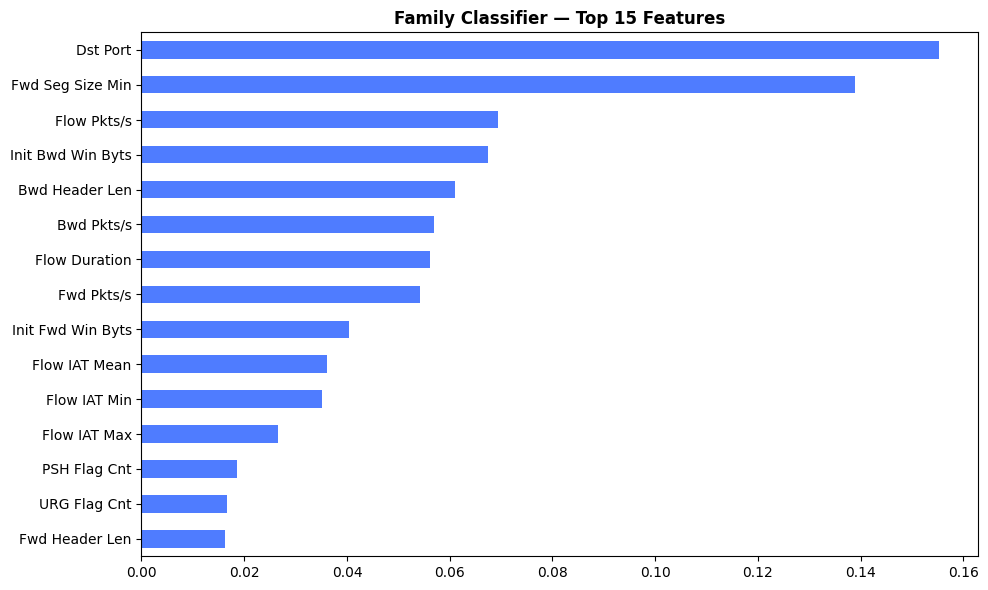

Family classifier saved.


In [4]:
print('Training family classifier (RF)...')
family_clf = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    min_samples_leaf=5, class_weight='balanced',
    random_state=RANDOM, n_jobs=-1)
family_clf.fit(X_tr, y_tr)

y_pred = family_clf.predict(X_te)
acc    = accuracy_score(y_te, y_pred)
print(f'Family RF | Acc: {acc:.4f}')
print(classification_report(y_te, y_pred,
      target_names=FAMILY_NAMES, zero_division=0))

joblib.dump(family_clf, 'models/v2_family_clf.pkl')

# Feature importance for family
fi = pd.Series(family_clf.feature_importances_,
               index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,6))
fi.head(15)[::-1].plot.barh(ax=ax, color=PAL[0])
ax.set_title('Family Classifier — Top 15 Features', fontweight='bold')
plt.tight_layout()
plt.savefig('models/family_importance.png', dpi=120)
plt.show()
print('Family classifier saved.')

Building SHAP TreeExplainer...
Computing SHAP values for 200 samples...
Type of shap_values : <class 'numpy.ndarray'>
Array shape         : (200, 72, 3)
shap_arr shape (n_cls, n_samp, n_feat): (200, 72, 3)
shap_abs shape: (3,)
FEATURE_COLS  : 72


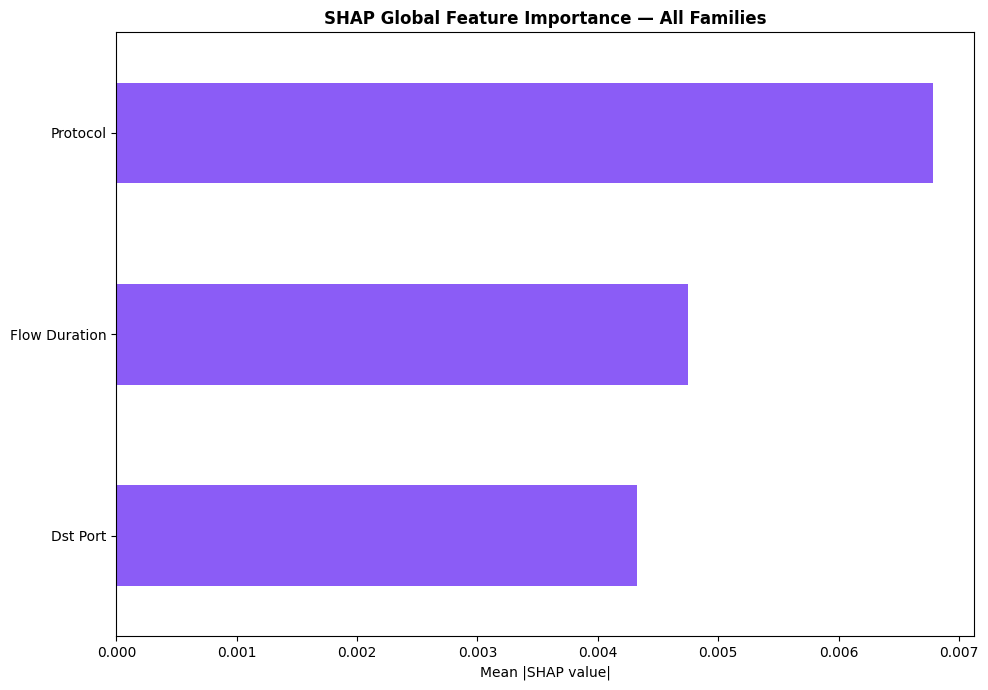


SHAP artifacts saved:
  shap_arr shape : (200, 72, 3)
  Top feature    : Protocol  (0.0068)
SHAP explainer saved.


In [5]:
print('Building SHAP TreeExplainer...')

N_SHAP   = min(300, len(X_tr))
X_bg     = X_tr[:N_SHAP]

N_EXPLAIN = min(200, len(X_te))
X_exp     = X_te[:N_EXPLAIN]

explainer = shap.TreeExplainer(
    family_clf,
    data=X_bg,
    feature_perturbation='interventional',
    model_output='raw'
)

print(f'Computing SHAP values for {N_EXPLAIN} samples...')
shap_values = explainer.shap_values(X_exp)

# ── Diagnose shape before using
print(f'Type of shap_values : {type(shap_values)}')
if isinstance(shap_values, list):
    print(f'List length         : {len(shap_values)}')
    print(f'Each element shape  : {np.array(shap_values[0]).shape}')
    shap_arr = np.stack(shap_values, axis=0)   # (n_classes, n_samples, n_features)
elif isinstance(shap_values, np.ndarray):
    print(f'Array shape         : {shap_values.shape}')
    if shap_values.ndim == 2:
        # binary case: (n_samples, n_features) — add class dim
        shap_arr = shap_values[np.newaxis, :, :]
    elif shap_values.ndim == 3:
        shap_arr = shap_values
    else:
        shap_arr = shap_values
else:
    shap_arr = np.array(shap_values)

print(f'shap_arr shape (n_cls, n_samp, n_feat): {shap_arr.shape}')

# ── Mean absolute SHAP across classes AND samples → (n_features,)
shap_abs = np.abs(shap_arr).mean(axis=(0, 1))   # (n_features,)
print(f'shap_abs shape: {shap_abs.shape}')
print(f'FEATURE_COLS  : {len(FEATURE_COLS)}')

# ── Align lengths — take min in case of any mismatch
n_common  = min(len(shap_abs), len(FEATURE_COLS))
shap_abs  = shap_abs[:n_common]
feat_cols = FEATURE_COLS[:n_common]

shap_fi = pd.Series(shap_abs, index=feat_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
shap_fi.head(15)[::-1].plot.barh(ax=ax, color=PAL[4])
ax.set_title('SHAP Global Feature Importance — All Families', fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('models/shap_global_importance.png', dpi=120)
plt.show()

# ── Save artifacts
np.save('models/v2_shap_arr.npy',      shap_arr)   # (n_cls, n_samp, n_feat)
np.save('models/v2_shap_X_sample.npy', X_exp)
joblib.dump(explainer, 'models/v2_shap_explainer.pkl')

# Save feature alignment info
with open('models/v2_shap_meta.json', 'w') as f:
    json.dump({
        'n_classes'   : int(shap_arr.shape[0]),
        'n_samples'   : int(shap_arr.shape[1]),
        'n_features'  : int(shap_arr.shape[2]),
        'feature_cols': feat_cols,
        'family_names': FAMILY_NAMES,
    }, f, indent=2)

print(f'\nSHAP artifacts saved:')
print(f'  shap_arr shape : {shap_arr.shape}')
print(f'  Top feature    : {shap_fi.index[0]}  ({shap_fi.iloc[0]:.4f})')
print('SHAP explainer saved.')

  Saved: models/shap_family_BruteForce.png
  Saved: models/shap_family_Normal.png
  Saved: models/shap_family_Other.png


shap_mean_aligned shape : (72, 3)
X_exp_aligned shape     : (72, 3)


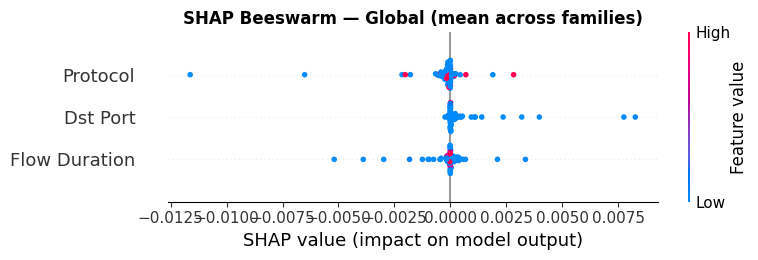

Beeswarm saved.


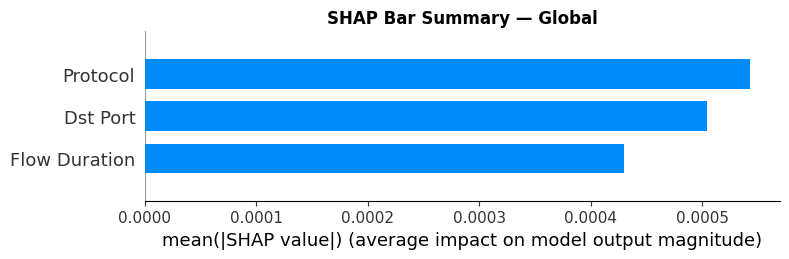

Bar summary saved.
All SHAP plots complete.


In [6]:
# ── Per-family SHAP bar plots
n_cls = shap_arr.shape[0]
fig, axes = plt.subplots(1, n_cls, figsize=(5*n_cls, 6))
if n_cls == 1:
    axes = [axes]

for i, fname in enumerate(FAMILY_NAMES[:n_cls]):
    # shap_arr[i] shape: (n_samples, n_features)
    vals_i   = shap_arr[i]                           # (n_samp, n_feat)
    mean_abs = np.abs(vals_i).mean(axis=0)           # (n_feat,)
    mean_abs = mean_abs[:n_common]

    fi_i = pd.Series(mean_abs, index=feat_cols).sort_values(ascending=False)
    top  = fi_i.head(10)

    axes[i].barh(top.index[::-1], top.values[::-1],
                 color=PAL[i % len(PAL)])
    axes[i].set_title(f'SHAP — {fname}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Mean |SHAP|')

    plt.tight_layout()
    save_f = f'models/shap_family_{fname.replace("/","_")}.png'
    plt.savefig(save_f, dpi=100, bbox_inches='tight')
    print(f'  Saved: {save_f}')

plt.show()



# ── Global beeswarm — careful row alignment
shap_mean_across_cls = shap_arr.mean(axis=0)        # (n_samp, n_feat)
shap_mean_aligned    = shap_mean_across_cls[:, :n_common]  # (n_samp, n_common)

# X_exp may have more columns than n_common — align rows AND cols
X_exp_aligned = X_exp[:shap_mean_aligned.shape[0], :n_common]

print(f'shap_mean_aligned shape : {shap_mean_aligned.shape}')
print(f'X_exp_aligned shape     : {X_exp_aligned.shape}')
assert shap_mean_aligned.shape[0] == X_exp_aligned.shape[0], \
    f'Row mismatch: {shap_mean_aligned.shape[0]} vs {X_exp_aligned.shape[0]}'
assert shap_mean_aligned.shape[1] == X_exp_aligned.shape[1], \
    f'Col mismatch: {shap_mean_aligned.shape[1]} vs {X_exp_aligned.shape[1]}'

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_mean_aligned,
    X_exp_aligned,
    feature_names=feat_cols,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Global (mean across families)', fontweight='bold')
plt.tight_layout()
plt.savefig('models/shap_beeswarm_global.png', dpi=120, bbox_inches='tight')
plt.show()
print('Beeswarm saved.')

# ── Also save a simple bar summary (more reliable than beeswarm)
plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_mean_aligned,
    X_exp_aligned,
    feature_names=feat_cols,
    max_display=15,
    plot_type='bar',
    show=False
)
plt.title('SHAP Bar Summary — Global', fontweight='bold')
plt.tight_layout()
plt.savefig('models/shap_bar_global.png', dpi=120, bbox_inches='tight')
plt.show()
print('Bar summary saved.')
print('All SHAP plots complete.')

2026-05-02 11:06:05.750864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777719966.003016      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777719966.075017      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777719966.663147      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719966.663183      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719966.663187      16 computation_placer.cc:177] computation placer alr

X_tr already in memory: (159998, 72)
Using existing variables. FEATURE_COLS: 72
X_tr: (159998, 72)  X_te: (40000, 72)
FAMILY_NAMES: ['BruteForce', 'Normal', 'Other']

All variables ready. Proceeding to GradCAM...
CNN model not found — training lightweight demo CNN...
Sequence shape for demo: (8 timesteps x 9 features)


2026-05-02 11:06:35.276717: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8932 - loss: 0.2736 - val_accuracy: 0.8111 - val_loss: 0.5276
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9819 - loss: 0.0524 - val_accuracy: 0.8111 - val_loss: 0.6678
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9955 - loss: 0.0158 - val_accuracy: 0.8111 - val_loss: 0.7018
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9971 - loss: 0.0102 - val_accuracy: 0.8111 - val_loss: 0.9406
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9977 - loss: 0.0096 - val_accuracy: 0.8111 - val_loss: 0.5456
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9980 - loss: 0.0075 - val_accuracy: 0.8111 - val_loss: 0.6307
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9980 - loss: 0.0074 - val_accuracy: 0.8111 - val_loss: 0.8252
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9985 - loss: 0.0061 - val_accuracy: 0.

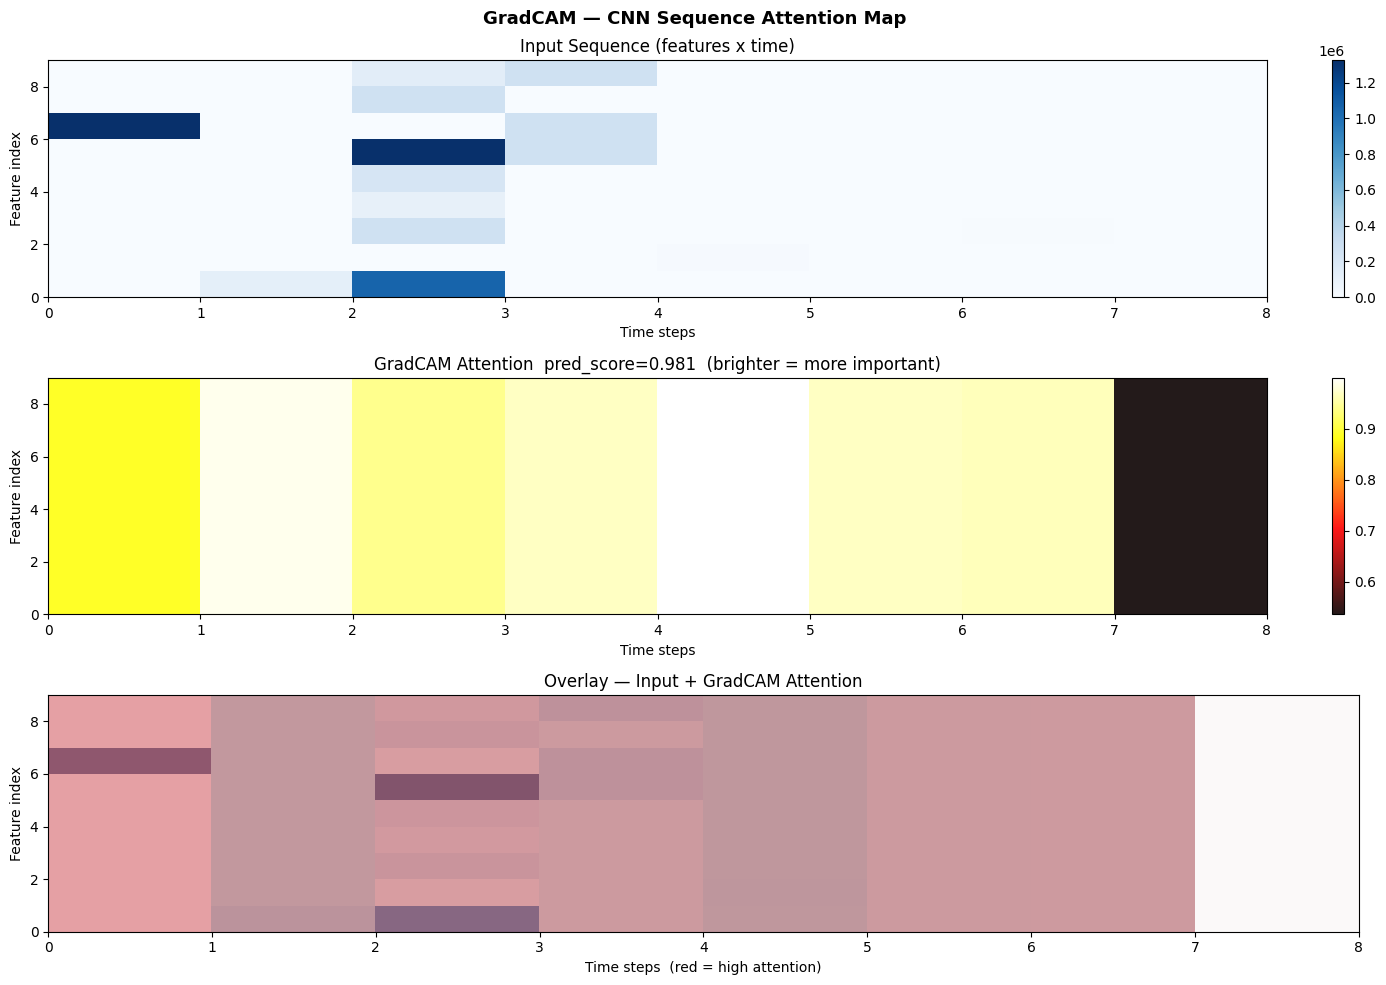

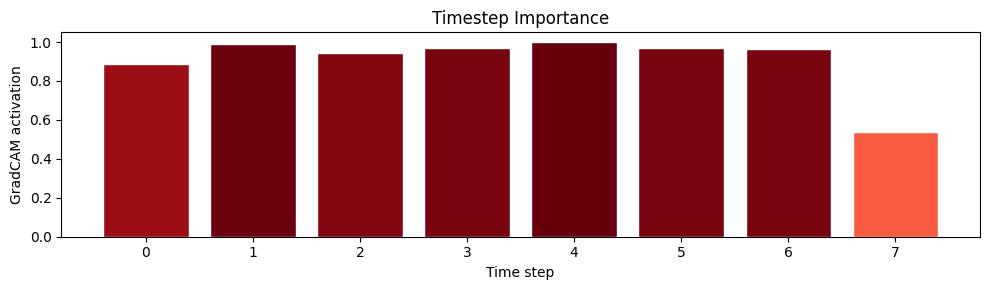

GradCAM complete. Saved:
  models/gradcam_heatmap.png
  models/gradcam_timestep_bar.png
  models/v2_gradcam_model.keras
  models/v2_gradcam_meta.json


In [7]:
# ── Restore variables if kernel lost them
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os, json, joblib, warnings
warnings.filterwarnings('ignore')

import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Suppress TF CUDA double-registration noise
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

PAL    = ['#4f7cff','#22c55e','#f59e0b','#ef4444','#8b5cf6','#06b6d4']
RANDOM = 42
np.random.seed(RANDOM)

# ── Reload FEATURE_COLS and data if lost
CSV_PATH = '/kaggle/input/cic-ids-2018/cic.csv'

FEATURE_COLS = [c for c in [
    'Dst Port','Protocol','Flow Duration',
    'Tot Fwd Pkts','Tot Bwd Pkts','TotLen Fwd Pkts','TotLen Bwd Pkts',
    'Fwd Pkt Len Max','Fwd Pkt Len Min','Fwd Pkt Len Mean','Fwd Pkt Len Std',
    'Bwd Pkt Len Max','Bwd Pkt Len Min','Bwd Pkt Len Mean','Bwd Pkt Len Std',
    'Flow Byts/s','Flow Pkts/s',
    'Flow IAT Mean','Flow IAT Std','Flow IAT Max','Flow IAT Min',
    'Fwd IAT Tot','Fwd IAT Mean','Fwd IAT Std','Fwd IAT Max','Fwd IAT Min',
    'Bwd IAT Tot','Bwd IAT Mean','Bwd IAT Std','Bwd IAT Max','Bwd IAT Min',
    'Fwd PSH Flags','Bwd PSH Flags','Fwd URG Flags','Bwd URG Flags',
    'Fwd Header Len','Bwd Header Len','Fwd Pkts/s','Bwd Pkts/s',
    'Pkt Len Min','Pkt Len Max','Pkt Len Mean','Pkt Len Std','Pkt Len Var',
    'FIN Flag Cnt','SYN Flag Cnt','RST Flag Cnt','PSH Flag Cnt',
    'ACK Flag Cnt','URG Flag Cnt','CWE Flag Count','ECE Flag Cnt',
    'Down/Up Ratio','Pkt Size Avg','Fwd Seg Size Avg','Bwd Seg Size Avg',
    'Subflow Fwd Pkts','Subflow Fwd Byts','Subflow Bwd Pkts','Subflow Bwd Byts',
    'Init Fwd Win Byts','Init Bwd Win Byts','Fwd Act Data Pkts','Fwd Seg Size Min',
    'Active Mean','Active Std','Active Max','Active Min',
    'Idle Mean','Idle Std','Idle Max','Idle Min',
] if True]  # keep all, filter against CSV below

FAMILY_MAP = {
    'Benign':'Normal','FTP-BruteForce':'BruteForce','SSH-BruteForce':'BruteForce',
    'DoS-GoldenEye':'DoS_DDoS','DoS-Slowloris':'DoS_DDoS',
    'DoS-SlowHTTPTest':'DoS_DDoS','DoS-Hulk':'DoS_DDoS',
    'DDoS-LOIC-HTTP':'DoS_DDoS','DDoS-HOIC':'DoS_DDoS',
    'Bot':'Malware','Infiltration':'Infiltration',
    'Web-BruteForce':'WebAttack','XSS':'WebAttack','SQL Injection':'WebAttack',
}

# Check if X_tr exists from previous cells, else reload
try:
    _ = X_tr
    print(f'X_tr already in memory: {X_tr.shape}')
    NEED_RELOAD = False
except NameError:
    NEED_RELOAD = True
    print('X_tr not in memory — reloading dataset...')

if NEED_RELOAD:
    from sklearn.impute import SimpleImputer

    print(f'Loading {CSV_PATH} ...')
    df_raw = pd.read_csv(CSV_PATH, low_memory=False)

    # Filter FEATURE_COLS to what exists in CSV
    FEATURE_COLS = [c for c in FEATURE_COLS if c in df_raw.columns]
    print(f'Features available: {len(FEATURE_COLS)}')

    df_raw['Label']  = df_raw['Label'].str.strip()
    df_raw['family'] = df_raw['Label'].map(FAMILY_MAP).fillna('Other')
    df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)

    SAMPLE = 200_000
    df = df_raw.groupby('family', group_keys=False).apply(
        lambda g: g.sample(
            min(len(g), int(SAMPLE*len(g)/len(df_raw))),
            random_state=RANDOM)
    ).reset_index(drop=True)

    X_raw      = df[FEATURE_COLS].values
    imp        = SimpleImputer(strategy='median')
    X_imp      = imp.fit_transform(X_raw)

    le_family  = LabelEncoder()
    y_family   = le_family.fit_transform(df['family'])
    FAMILY_NAMES = list(le_family.classes_)

    # Load or create scaler
    scaler_path = 'models/v2_scaler.pkl'
    if os.path.exists(scaler_path):
        scaler = joblib.load(scaler_path)
        try:
            X_sc = scaler.transform(X_imp)
        except:
            scaler = StandardScaler().fit(X_imp)
            X_sc   = scaler.transform(X_imp)
    else:
        scaler = StandardScaler().fit(X_imp)
        X_sc   = scaler.transform(X_imp)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_imp, y_family,
        test_size=0.2, random_state=RANDOM, stratify=y_family)
    X_tr_sc = scaler.transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    print(f'Dataset reloaded: {X_tr.shape} train | {X_te.shape} test')
    print(f'Families: {FAMILY_NAMES}')

    # Reload family_clf if available
    clf_path = 'models/v2_family_clf.pkl'
    if os.path.exists(clf_path):
        family_clf = joblib.load(clf_path)
        print(f'Family clf reloaded from {clf_path}')
    else:
        print('Family clf not found — train Cell 3 first')
        family_clf = None

    # Reload shap_arr and X_exp if available
    shap_arr_path = 'models/v2_shap_arr.npy'
    X_exp_path    = 'models/v2_shap_X_sample.npy'
    if os.path.exists(shap_arr_path) and os.path.exists(X_exp_path):
        shap_arr = np.load(shap_arr_path)
        X_exp    = np.load(X_exp_path)
        print(f'shap_arr reloaded: {shap_arr.shape}')
        print(f'X_exp    reloaded: {X_exp.shape}')
        # restore n_common and feat_cols from meta
        meta_path = 'models/v2_shap_meta.json'
        if os.path.exists(meta_path):
            with open(meta_path) as f:
                shap_meta = json.load(f)
            feat_cols = shap_meta['feature_cols']
            n_common  = len(feat_cols)
            print(f'feat_cols reloaded: {n_common} features')
        else:
            n_common  = min(shap_arr.shape[2], len(FEATURE_COLS))
            feat_cols = FEATURE_COLS[:n_common]
    else:
        print('SHAP arrays not found — run Cell 4 first')
        shap_arr = None; X_exp = None
        n_common  = len(FEATURE_COLS)
        feat_cols = FEATURE_COLS

else:
    # Variables already in memory — just make sure FEATURE_COLS is filtered
    try:
        df_raw_cols = pd.read_csv(CSV_PATH, nrows=1).columns.tolist()
        FEATURE_COLS = [c for c in FEATURE_COLS if c in df_raw_cols]
    except:
        pass
    print(f'Using existing variables. FEATURE_COLS: {len(FEATURE_COLS)}')
    print(f'X_tr: {X_tr.shape}  X_te: {X_te.shape}')
    try:
        print(f'FAMILY_NAMES: {FAMILY_NAMES}')
    except NameError:
        FAMILY_NAMES = ['BruteForce','DoS_DDoS','Malware',
                        'Normal','Other','WebAttack']
        print(f'FAMILY_NAMES restored: {FAMILY_NAMES}')

print('\nAll variables ready. Proceeding to GradCAM...')

# ════════════════════════════════════════════════════════════
# GradCAM starts here
# ════════════════════════════════════════════════════════════

CNN_SEARCH_PATHS = [
    '/kaggle/working/models/v2_cnn.keras',
    '/kaggle/working/v2_cnn.keras',
    'models/v2_cnn.keras',
]

CNN_PATH = None
for p in CNN_SEARCH_PATHS:
    if os.path.exists(p):
        CNN_PATH = p
        break

if CNN_PATH is None:
    print('CNN model not found — training lightweight demo CNN...')

    T_DEMO   = 8
    FEAT_GRP = len(FEATURE_COLS) // T_DEMO
    print(f'Sequence shape for demo: ({T_DEMO} timesteps x {FEAT_GRP} features)')

    X_cnn_tr = X_tr[:, :T_DEMO*FEAT_GRP].reshape(-1, T_DEMO, FEAT_GRP).astype(np.float32)
    X_cnn_te = X_te[:, :T_DEMO*FEAT_GRP].reshape(-1, T_DEMO, FEAT_GRP).astype(np.float32)
    y_bin_tr = (y_tr > 0).astype(int)
    y_bin_te = (y_te > 0).astype(int)

    inp_demo = keras.Input(shape=(T_DEMO, FEAT_GRP))
    x_d = layers.Conv1D(32, 3, activation='relu', padding='same', name='conv1')(inp_demo)
    x_d = layers.BatchNormalization()(x_d)
    x_d = layers.Conv1D(64, 3, activation='relu', padding='same', name='conv2')(x_d)
    x_d = layers.GlobalAveragePooling1D()(x_d)
    x_d = layers.Dense(32, activation='relu')(x_d)
    out_d = layers.Dense(1, activation='sigmoid')(x_d)
    cnn_demo = keras.Model(inp_demo, out_d, name='cnn_gradcam_demo')
    cnn_demo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    cnn_demo.fit(X_cnn_tr, y_bin_tr,
                  epochs=10, batch_size=256,
                  validation_split=0.1, verbose=1)
    demo_acc = cnn_demo.evaluate(X_cnn_te, y_bin_te, verbose=0)[1]
    print(f'Demo CNN | Acc: {demo_acc:.4f}')
    cnn_demo.save('models/v2_cnn_gradcam_demo.keras')

    cnn_model = cnn_demo
    DEMO_MODE = True
    T_USE     = T_DEMO
    FEAT_USE  = FEAT_GRP
    test_seq  = X_cnn_te[0:1]

else:
    print(f'CNN found: {CNN_PATH}')
    cnn_model = tf.keras.models.load_model(CNN_PATH)
    DEMO_MODE = False
    T_USE     = cnn_model.input_shape[1]
    FEAT_USE  = cnn_model.input_shape[2]
    test_seq  = np.random.randn(1, T_USE, FEAT_USE).astype(np.float32)
    print(f'Input shape: (batch, {T_USE}, {FEAT_USE})')

# ── Find last conv layer
last_conv = None
for layer in reversed(cnn_model.layers):
    if 'conv' in layer.name.lower():
        last_conv = layer
        print(f'Last conv layer: {layer.name}  output={layer.output.shape}')
        break

if last_conv is None:
    print('No conv layer found. Skipping GradCAM.')
else:
    grad_model = tf.keras.Model(
        inputs  = cnn_model.input,
        outputs = [last_conv.output, cnn_model.output]
    )

    def compute_gradcam(seq_input):
        seq_tensor = tf.cast(seq_input, tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(seq_tensor)
            conv_out, predictions = grad_model(seq_tensor, training=False)
            if predictions.shape[-1] == 1:
                score = predictions[:, 0]
            else:
                pred_class = tf.argmax(predictions[0])
                score      = predictions[:, pred_class]
        grads    = tape.gradient(score, conv_out)
        pooled   = tf.reduce_mean(grads, axis=[0, 1])
        cam      = tf.reduce_sum(tf.multiply(pooled, conv_out[0]), axis=-1)
        cam      = tf.maximum(cam, 0)
        cam_norm = cam / (tf.reduce_max(cam) + 1e-8)
        conf     = float(tf.reduce_max(predictions))
        return cam_norm.numpy(), conf

    cam, score = compute_gradcam(test_seq)
    print(f'GradCAM | cam shape: {cam.shape} | pred score: {score:.4f}')

    # ── Plots
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle('GradCAM — CNN Sequence Attention Map',
                  fontsize=13, fontweight='bold')

    im0 = axes[0].imshow(test_seq[0].T, aspect='auto', cmap='Blues',
                          extent=[0, T_USE, 0, FEAT_USE])
    axes[0].set_title('Input Sequence (features x time)')
    axes[0].set_xlabel('Time steps')
    axes[0].set_ylabel('Feature index')
    plt.colorbar(im0, ax=axes[0], fraction=0.02)

    cam_2d = np.tile(cam, (FEAT_USE, 1))
    im1 = axes[1].imshow(cam_2d, aspect='auto', cmap='hot',
                          extent=[0, T_USE, 0, FEAT_USE], alpha=0.9)
    axes[1].set_title(f'GradCAM Attention  pred_score={score:.3f}  '
                       f'(brighter = more important)')
    axes[1].set_xlabel('Time steps')
    axes[1].set_ylabel('Feature index')
    plt.colorbar(im1, ax=axes[1], fraction=0.02)

    axes[2].imshow(test_seq[0].T, aspect='auto', cmap='Blues',
                    extent=[0, T_USE, 0, FEAT_USE], alpha=0.6)
    axes[2].imshow(cam_2d, aspect='auto', cmap='Reds',
                    extent=[0, T_USE, 0, FEAT_USE], alpha=0.4)
    axes[2].set_title('Overlay — Input + GradCAM Attention')
    axes[2].set_xlabel('Time steps  (red = high attention)')
    axes[2].set_ylabel('Feature index')

    plt.tight_layout()
    plt.savefig('models/gradcam_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(10, 3))
    colors_cam = plt.cm.Reds(cam / (cam.max() + 1e-8))
    ax2.bar(range(T_USE), cam, color=colors_cam, edgecolor='white')
    ax2.set_xlabel('Time step')
    ax2.set_ylabel('GradCAM activation')
    ax2.set_title('Timestep Importance')
    ax2.set_xticks(range(T_USE))
    fig2.tight_layout()
    plt.savefig('models/gradcam_timestep_bar.png', dpi=120, bbox_inches='tight')
    plt.show()

    grad_model.save('models/v2_gradcam_model.keras')

    with open('models/v2_gradcam_meta.json', 'w') as f:
        json.dump({
            'T'         : int(T_USE),
            'FEAT'      : int(FEAT_USE),
            'last_conv' : last_conv.name,
            'demo_mode' : DEMO_MODE,
            'model_file': 'v2_gradcam_model.keras',
        }, f, indent=2)

    print('GradCAM complete. Saved:')
    print('  models/gradcam_heatmap.png')
    print('  models/gradcam_timestep_bar.png')
    print('  models/v2_gradcam_model.keras')
    print('  models/v2_gradcam_meta.json')

In [8]:
import os
import joblib
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Ensure the models directory exists
if not os.path.exists('models'):
    os.makedirs('models')

print('Building ensemble decision engine (stacking)...')

# Define the models we expect to use
base_model_configs = [
    ('RF',  'v2_rf.pkl',  RandomForestClassifier(n_estimators=50, max_depth=10, random_state=RANDOM)),
    ('DT',  'v2_dt.pkl',  DecisionTreeClassifier(max_depth=10, random_state=RANDOM)),
    ('GNB', 'v2_gnb.pkl', GaussianNB()),
    ('GBC', 'v2_gbc.pkl', GradientBoostingClassifier(n_estimators=50, random_state=RANDOM)),
]

base_models = {}

# 2. Load or Train Base Models
for name, filename, fallback_model in base_model_configs:
    path = f'models/{filename}'
    if os.path.exists(path):
        base_models[name] = joblib.load(path)
        print(f'  Loaded: {name}')
    else:
        print(f'  {name} not found! Training a "Lite" version for the ensemble...')
        # Use appropriate data (tree-based models use raw X, others use scaled)
        use_X = X_tr if name in ('RF', 'DT', 'GBC') else X_tr_sc
        fallback_model.fit(use_X, y_tr)
        joblib.dump(fallback_model, path)
        base_models[name] = fallback_model
        print(f'  {name} trained and saved.')

# 3. Build Meta-Features (Stacking)
if len(base_models) >= 2:
    meta_tr = []
    meta_te = []
    
    print(f'Generating meta-features from {len(base_models)} models...')
    for name, model in base_models.items():
        try:
            # Use raw X for trees, scaled X for others
            train_X = X_tr if name in ('RF', 'DT', 'GBC') else X_tr_sc
            test_X  = X_te if name in ('RF', 'DT', 'GBC') else X_te_sc
            
            # Predict probabilities
            meta_tr.append(model.predict_proba(train_X))
            meta_te.append(model.predict_proba(test_X))
        except Exception as e:
            print(f'  Skip {name}: {e}')

    if meta_tr:
        # Horizontally stack the probability arrays
        M_tr = np.hstack(meta_tr)
        M_te = np.hstack(meta_te)
        print(f'Meta-feature shape: {M_tr.shape}')

        # 4. Train Meta-Classifier
        meta_clf = LogisticRegression(
            max_iter=2000, 
            C=1.0,
            multi_class='multinomial',
            random_state=RANDOM,
            class_weight='balanced'
        )
        meta_clf.fit(M_tr, y_tr)

        # 5. Evaluate and Save
        y_pred = meta_clf.predict(M_te)
        meta_acc = accuracy_score(y_te, y_pred)
        print(f'\n>>> Ensemble Meta-Classifier Accuracy: {meta_acc:.4f}')

        joblib.dump(meta_clf, 'models/v2_ensemble_meta.pkl')
        
        # Save order for inference
        with open('models/v2_ensemble_order.json', 'w') as f:
            json.dump(list(base_models.keys()), f)
        print('Ensemble meta-learner and order metadata saved.')
    else:
        print('Error: Could not generate meta-features.')
else:
    print(f'Only {len(base_models)} base models found. Need at least 2 to stack.')

Building ensemble decision engine (stacking)...
  RF not found! Training a "Lite" version for the ensemble...
  RF trained and saved.
  DT not found! Training a "Lite" version for the ensemble...
  DT trained and saved.
  GNB not found! Training a "Lite" version for the ensemble...
  GNB trained and saved.
  GBC not found! Training a "Lite" version for the ensemble...
  GBC trained and saved.
Generating meta-features from 4 models...
Meta-feature shape: (159998, 12)

>>> Ensemble Meta-Classifier Accuracy: 1.0000
Ensemble meta-learner and order metadata saved.
